In [1]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex=False)
mpl.rc('font', family='serif')
mpl.rc('font', size='14')
mpl.rc('xtick', labelsize=14)
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'


In [2]:
dir = "./data/broad_resonance/"

# Factor de escala $a(\\tilde\\eta)$

Columnas: $\\tilde\\eta$ | $a$ | $a'$ | $a'/a$

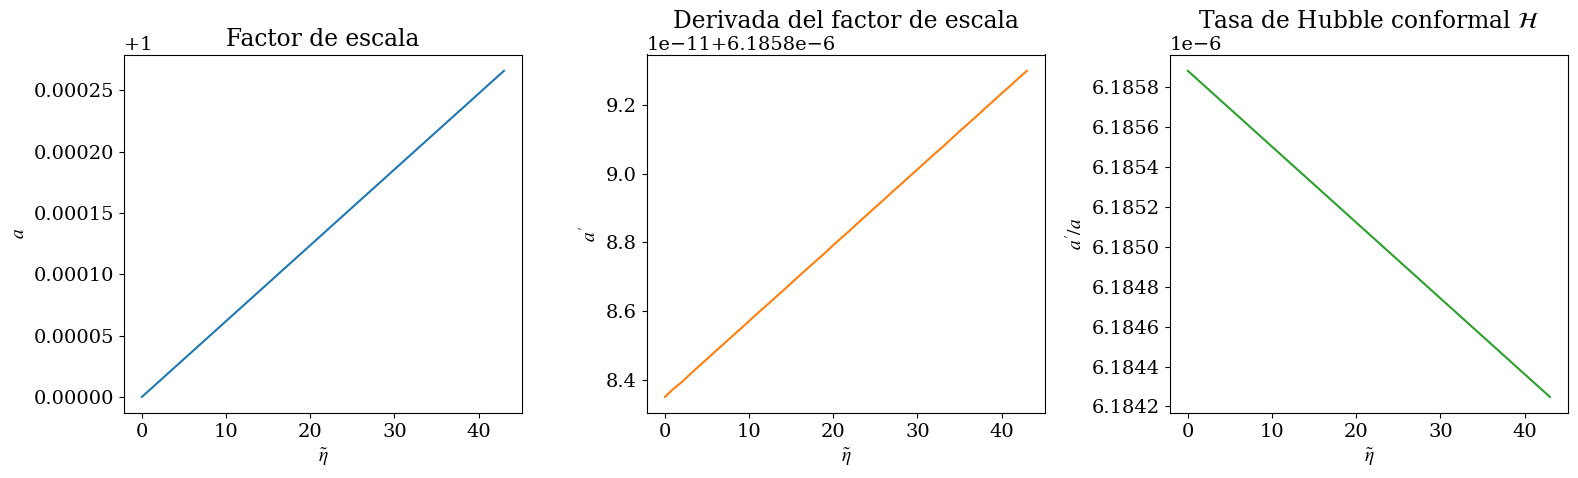

In [3]:
aDat = np.loadtxt(dir + "average_scale_factor.txt")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(aDat[:,0], aDat[:,1], color='tab:blue')
axes[0].set_xlabel(r'$\tilde\eta$')
axes[0].set_ylabel(r'$a$')
axes[0].set_title(r'Factor de escala')

axes[1].plot(aDat[:,0], aDat[:,2], color='tab:orange')
axes[1].set_xlabel(r'$\tilde\eta$')
axes[1].set_ylabel(r"$a'$")
axes[1].set_title(r"Derivada del factor de escala")

axes[2].plot(aDat[:,0], aDat[:,3], color='tab:green')
axes[2].set_xlabel(r'$\tilde\eta$')
axes[2].set_ylabel(r"$a'/a$")
axes[2].set_title(r"Tasa de Hubble conformal $\mathcal{H}$")

plt.tight_layout()
plt.show()


# Promedios volumétricos de los campos

Columnas: $\\tilde\\eta$ | $\\langle\\tilde\\phi\\rangle$ | $\\langle\\tilde\\phi'\\rangle$ | $\\langle\\tilde\\phi^2\\rangle$ | $\\langle\\tilde\\phi'^2\\rangle$ | $\\mathrm{rms}(\\tilde\\phi)$ | $\\mathrm{rms}(\\tilde\\phi')$

**Nota**: Para el inflatón se grafica $\\langle\\phi\\rangle$ (oscilación coherente).  
Para el campo hijo, el promedio $\\langle\\chi\\rangle \\approx 0$ por simetría $\\chi\\to-\\chi$, así que el observable relevante es el **rms** (columna 5), que mide el crecimiento de fluctuaciones.

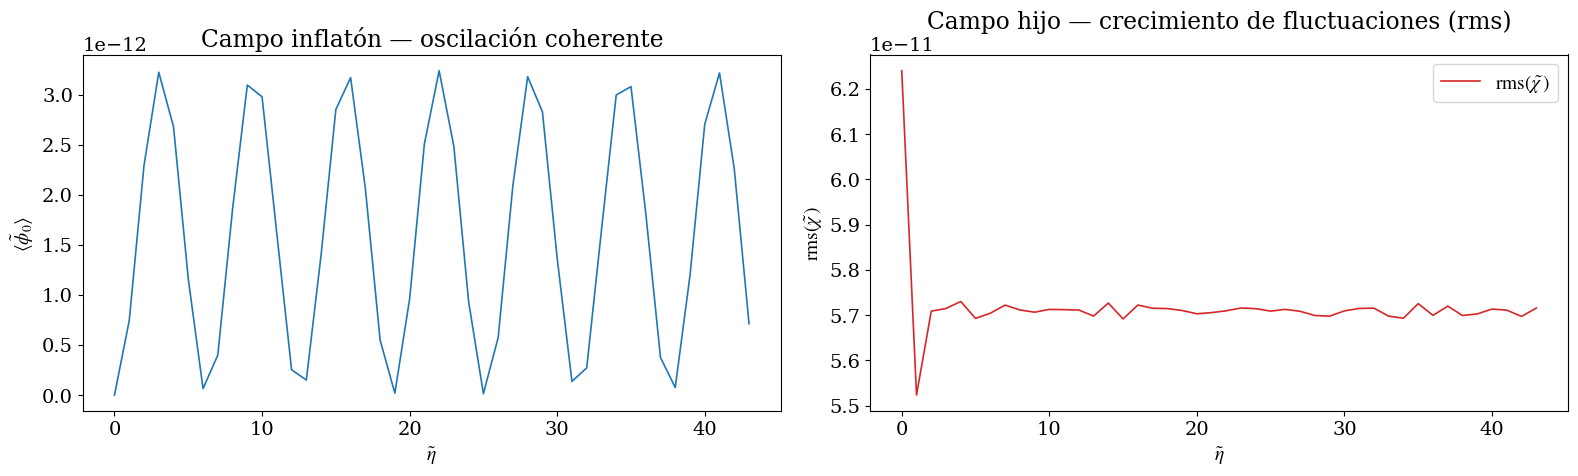

In [4]:
infDat = np.loadtxt(dir + "average_scalar_0.txt")
chiDat = np.loadtxt(dir + "average_scalar_1.txt")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Inflatón: promedio coherente
axes[0].plot(infDat[:,0], infDat[:,1], color='tab:blue', lw=1.2)
axes[0].set_xlabel(r'$\tilde\eta$')
axes[0].set_ylabel(r'$\langle\tilde\phi_0\rangle$')
axes[0].set_title(r'Campo inflatón — oscilación coherente')

# Campo hijo: rms (columna 5, índice 4) — el promedio es ~0 por simetría Z2
axes[1].plot(chiDat[:,0], chiDat[:,4], color='tab:red', lw=1.2, label=r'$\mathrm{rms}(\tilde\chi)$')
axes[1].set_xlabel(r'$\tilde\eta$')
axes[1].set_ylabel(r'$\mathrm{rms}(\tilde\chi)$')
axes[1].set_title(r'Campo hijo — crecimiento de fluctuaciones (rms)')
axes[1].legend()

plt.tight_layout()
plt.show()


# Conservación de energía (1ª ecuación de Friedmann)

Columnas: $\\tilde\\eta$ | $(\\langle LHS-RHS\\rangle)/(\\langle LHS+RHS\\rangle)$ | $\\langle LHS\\rangle$ | $\\langle RHS\\rangle$

Un valor $\\lesssim 10^{-4}$ indica buena conservación. Si crece monotónicamente, revisar `kCutOff` y `dt`.

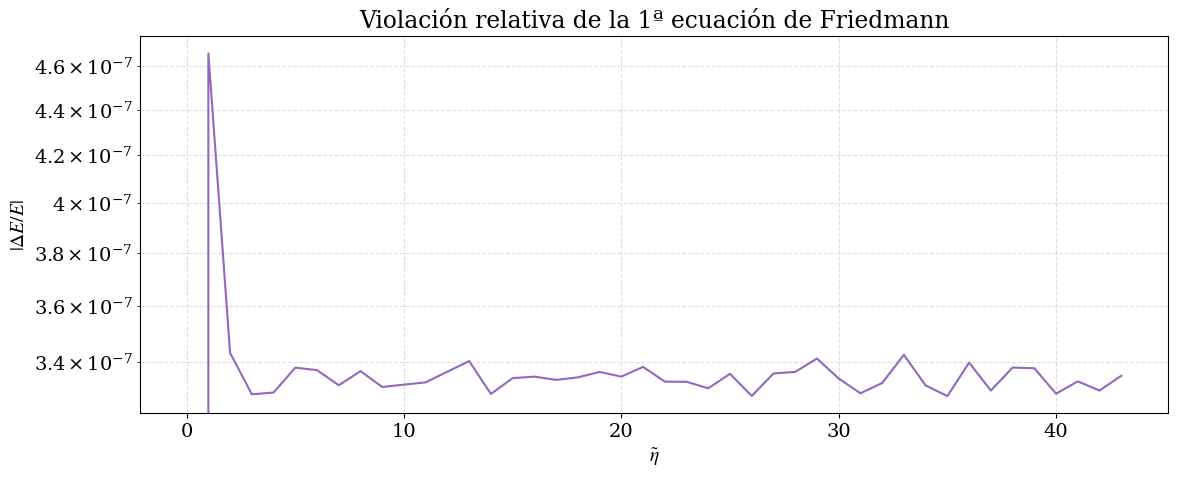

Violación máxima: 4.66e-07
Violación final:  3.35e-07


In [5]:
enConsDat = np.loadtxt(dir + "average_energy_conservation.txt")

plt.figure(figsize=(12, 5))
plt.plot(enConsDat[:,0], np.abs(enConsDat[:,1]), color='tab:purple', lw=1.5)
plt.yscale('log')
plt.xlabel(r'$\tilde\eta$')
plt.ylabel(r'$|\Delta E / E|$')
plt.title(r'Violación relativa de la 1ª ecuación de Friedmann')
plt.grid(True, which='both', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Violación máxima: {np.max(np.abs(enConsDat[:,1])):.2e}")
print(f"Violación final:  {np.abs(enConsDat[-1,1]):.2e}")


# Densidades de energía

Columnas de `average_energies.txt`:
$\\tilde\\eta$ | $E_K^{(0)}$ | $E_G^{(0)}$ | $E_K^{(1)}$ | $E_G^{(1)}$ | $E_{V_0}$ | $E_{V_1}$ | $\\langle\\tilde\\rho\\rangle$

**Nota importante**: Las energías en unidades del programa ya son adimensionales y no necesitan reescalado por $a^4$. La densidad total $\\langle\\tilde\\rho\\rangle$ (última columna) sí debe caer como $a^{-4}$ (radiación dominante durante preheating).

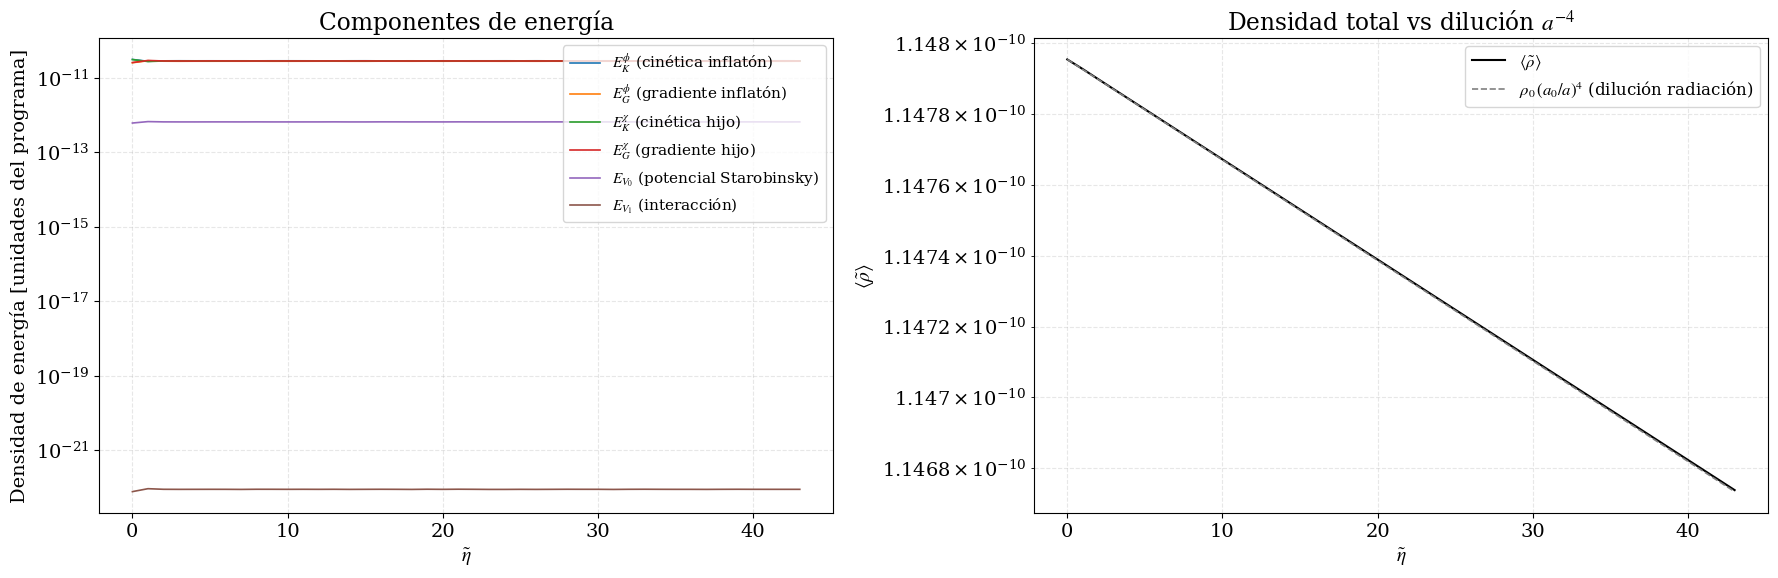

In [6]:
enDat = np.loadtxt(dir + "average_energies.txt")

# Columnas: 0=t, 1=EK0, 2=EG0, 3=EK1, 4=EG1, 5=EV0, 6=EV1, 7=rho_total
labels  = ["$E_K^{\\phi}$ (cinética inflatón)",
           "$E_G^{\\phi}$ (gradiente inflatón)",
           "$E_K^{\\chi}$ (cinética hijo)",
           "$E_G^{\\chi}$ (gradiente hijo)",
           "$E_{V_0}$ (potencial Starobinsky)",
           "$E_{V_1}$ (interacción)",
           r"$\langle\tilde\rho\rangle$ (densidad total)"]
colors = ["tab:blue","tab:orange","tab:green","tab:red","tab:purple","tab:brown","black"]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Panel izquierdo: componentes individuales (sin rho total)
for i in range(1, 7):
    axes[0].plot(enDat[:,0], enDat[:,i], color=colors[i-1], label=labels[i-1], lw=1.2)
axes[0].set_yscale('log')
axes[0].set_xlabel(r'$\tilde\eta$')
axes[0].set_ylabel(r'Densidad de energía [unidades del programa]')
axes[0].set_title('Componentes de energía')
axes[0].legend(fontsize=11, loc='upper right')
axes[0].grid(True, which='both', ls='--', alpha=0.3)

# Panel derecho: densidad total vs a^{-4} (chequeo de dilución)
rho = enDat[:,7]
a   = aDat[:,1]
axes[1].plot(enDat[:,0], rho, color='black', label=r'$\langle\tilde\rho\rangle$', lw=1.5)
axes[1].plot(enDat[:,0], rho[0]*a[0]**4/a**4, color='gray', ls='--', lw=1.2,
             label=r'$\rho_0\,(a_0/a)^4$ (dilución radiación)')
axes[1].set_yscale('log')
axes[1].set_xlabel(r'$\tilde\eta$')
axes[1].set_ylabel(r'$\langle\tilde\rho\rangle$')
axes[1].set_title(r'Densidad total vs dilución $a^{-4}$')
axes[1].legend(fontsize=12)
axes[1].grid(True, which='both', ls='--', alpha=0.3)

plt.tight_layout()
plt.show()


# Espectros de potencias

Estructura de los archivos de espectros escalares (4 columnas):  
$\\tilde k$ | $\\tilde\\Delta_{\\tilde\\phi}$ | $\\tilde\\Delta_{\\tilde\\phi'}$ | $\\tilde n_{\\tilde\\phi}$ | multiplicidad de bin

Estructura del archivo de GWs (3 columnas):  
$\\tilde k$ | $\\tilde\\Omega_{GW}$ | multiplicidad de bin

Los tiempos de los snapshots están en `average_spectra_times.txt`.

In [7]:
def load_spectrum(filename, comment='#'):
    """Carga un archivo de espectros con bloques separados por líneas en blanco."""
    file = open(filename)
    nBins = 0
    line = file.readline()
    while line != '\n' and line != '':
        if line[0] != comment:
            nBins += 1
        line = file.readline()
    file.close()

    data = np.loadtxt(filename, comments=comment)
    nSpectra = len(data) // nBins
    return data, nBins, nSpectra


def plot_spectrum(ax, spectra, column, nBins, nSpectra, times=None, colormap='plasma', ylabel=''):
    """Grafica todos los snapshots de un espectro con colormap de tiempo."""
    cmap = plt.get_cmap(colormap)
    for i in range(nSpectra):
        block = spectra[i*nBins:(i+1)*nBins, :]
        color = cmap(i / max(nSpectra-1, 1))
        y = block[:, column]
        # Evitar log(0): solo graficar donde y > 0
        mask = y > 0
        if mask.sum() > 1:
            ax.plot(block[mask, 0], y[mask], color=color, lw=1.2)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\tilde k$', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.grid(True, which='both', ls='--', alpha=0.3)

    # Barra de color para el tiempo
    if times is not None:
        norm = mpl.colors.Normalize(vmin=times[0], vmax=times[-1])
        sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, pad=0.02)
        cbar.set_label(r'$\tilde\eta$', fontsize=13, rotation=0, labelpad=10)

# Cargar tiempos de los snapshots
sp_times = np.loadtxt(dir + "average_spectra_times.txt")
print(f"Snapshots de espectros en tiempos: {sp_times}")


Snapshots de espectros en tiempos: 0.0


In [8]:
# ---- Inflatón ----
infSp, nBins0, nSp0 = load_spectrum(dir + "spectra_scalar_0.txt")
print(f"Inflatón: {nBins0} bins, {nSp0} snapshots")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(r'Espectro del inflatón $\tilde\phi_0$', fontsize=15)

plot_spectrum(axes[0], infSp, 1, nBins0, nSp0, sp_times,
              ylabel=r'$\tilde\Delta_{\tilde\phi_0}$')
axes[0].set_title(r'Espectro de potencias $\Delta$')

plot_spectrum(axes[1], infSp, 3, nBins0, nSp0, sp_times,
              ylabel=r'$\tilde n_{\tilde\phi_0}$')
axes[1].set_title(r'Número de ocupación')

plt.tight_layout()
plt.show()


/tmp/ipykernel_125492/3328355102.py:12: UserWarning: loadtxt: input contained no data: "./data/broad_resonance/spectra_scalar_0.txt"
  data = np.loadtxt(filename, comments=comment)


ZeroDivisionError: integer division or modulo by zero

In [ ]:
# ---- Campo hijo ----
chiSp, nBins1, nSp1 = load_spectrum(dir + "spectra_scalar_1.txt")
print(f"Campo hijo: {nBins1} bins, {nSp1} snapshots")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(r'Espectro del campo hijo $\tilde\chi$', fontsize=15)

plot_spectrum(axes[0], chiSp, 1, nBins1, nSp1, sp_times,
              ylabel=r'$\tilde\Delta_{\tilde\chi}$')
axes[0].set_title(r'Espectro de potencias $\Delta$')

plot_spectrum(axes[1], chiSp, 3, nBins1, nSp1, sp_times,
              ylabel=r'$\tilde n_{\tilde\chi}$')
axes[1].set_title(r'Número de ocupación')

plt.tight_layout()
plt.show()


In [ ]:
# ---- Ondas Gravitacionales ----
# El archivo de GWs tiene 3 columnas: k | Omega_GW | multiplicidad
# (a diferencia de los escalares que tienen 4 columnas)
gwSp, nBinsGW, nSpGW = load_spectrum(dir + "spectra_gws.txt")
print(f"GWs: {nBinsGW} bins, {nSpGW} snapshots")

# El primer snapshot (t=0) tiene Omega_GW = 0, empezamos desde el segundo
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(r'Ondas Gravitacionales', fontsize=15)

plot_spectrum(axes[0], gwSp, 1, nBinsGW, nSpGW, sp_times,
              ylabel=r'$\tilde\Omega_{GW}(k)$')
axes[0].set_title(r'Espectro de GWs')

# Energía total en GWs por snapshot (integración trapezoidal en log-k)
E_gw = []
for i in range(nSpGW):
    block = gwSp[i*nBinsGW:(i+1)*nBinsGW, :]
    mask = block[:,1] > 0
    if mask.sum() > 1:
        E_gw.append(np.trapz(block[mask,1], block[mask,0]))
    else:
        E_gw.append(0)

axes[1].plot(sp_times[:len(E_gw)], E_gw, 'o-', color='black', lw=1.5)
axes[1].set_yscale('log')
axes[1].set_xlabel(r'$\tilde\eta$')
axes[1].set_ylabel(r'$\int \tilde\Omega_{GW}\, dk$')
axes[1].set_title(r'Energía total en GWs vs tiempo')
axes[1].grid(True, which='both', ls='--', alpha=0.3)

plt.tight_layout()
plt.show()


# Resumen del estado de la simulación

- **`kCutOff = 100`** en el `.infos` → todavía está usando el valor viejo. Cambiarlo a `kCutOff = 4` en el `.in` y recompilar.
- Con `q = (g/κ)² = 1` estamos en **broad resonance**. El campo hijo crece exponencialmente pero puede tomar muchas oscilaciones del inflatón (~100+) para que sea visible en los espectros.
- La densidad total debería seguir $\langle\tilde\rho\rangle \propto a^{-4}$ durante el preheating. Si se desvía, indica transferencia de energía al campo hijo.
- Para ver el preheating completamente, se necesita extender `tMax` a ~500–1000.